# CMM704 Coursework - Question 2

## Air Quality Clustering and Drift Analysis

This notebook implements the full plan from `README.md`:
- robust parsing and quality checks
- EDA and temporal analysis
- preprocessing fitted on Period A only
- KMeans search and final models for A/B
- cluster profiling and drift analysis
- PCA + monthly cluster evolution
- export artifacts to `notebooks/Q2/outputs/`

Locked choices:
- strict windows: A = 2004-03-01..2004-08-31, B = 2004-09-01..2005-03-31
- fit imputer/scaler on A only
- primary features = sensor + meteorological columns


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from scipy.stats import entropy

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples
from sklearn.decomposition import PCA

from IPython.display import display

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
A_START = '2004-03-01'
A_END = '2004-08-31 23:59:59'
B_START = '2004-09-01'
B_END = '2005-03-31 23:59:59'

def find_project_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / 'README.md').exists() and (p / 'data').exists() and (p / 'notebooks').exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'Q2' / 'raw' / 'AirQualityUCI.csv'
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'Q2' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print('Project root:', PROJECT_ROOT)
print('Data path   :', DATA_PATH)
print('Output dir  :', OUTPUT_DIR)


Project root: D:\MSc\CMM704 Data Mining\Coursework
Data path   : D:\MSc\CMM704 Data Mining\Coursework\data\Q2\raw\AirQualityUCI.csv
Output dir  : D:\MSc\CMM704 Data Mining\Coursework\notebooks\Q2\outputs


In [2]:
def load_airquality(path: str | Path) -> pd.DataFrame:
    return pd.read_csv(path, sep=';', dtype=str)


def prepare_datetime_and_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    drop_cols = [c for c in out.columns if str(c).startswith('Unnamed') or str(c).strip() == '']
    if drop_cols:
        out = out.drop(columns=drop_cols)
    out = out.dropna(axis=1, how='all')

    for c in out.columns:
        out[c] = out[c].astype(str).str.strip()

    out['Datetime'] = pd.to_datetime(
        out['Date'] + ' ' + out['Time'],
        dayfirst=True,
        format='%d/%m/%Y %H.%M.%S',
        errors='coerce',
    )

    numeric_cols = [c for c in out.columns if c not in ['Date', 'Time', 'Datetime']]
    for c in numeric_cols:
        cleaned = out[c].replace({'-200': np.nan, '': np.nan, 'nan': np.nan, 'NaN': np.nan}).str.replace(',', '.', regex=False)
        out[c] = pd.to_numeric(cleaned, errors='coerce')

    out = out.dropna(subset=['Datetime']).copy()
    out = out.sort_values('Datetime').reset_index(drop=True)
    return out


def get_feature_groups(df: pd.DataFrame) -> dict[str, list[str]]:
    pollutant_reference_cols = [c for c in ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)'] if c in df.columns]
    sensor_cols = [c for c in ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)'] if c in df.columns]
    meteo_cols = [c for c in ['T', 'RH', 'AH'] if c in df.columns]
    return {
        'pollutant_reference_cols': pollutant_reference_cols,
        'sensor_cols': sensor_cols,
        'meteo_cols': meteo_cols,
    }


def compute_iqr_clip_bounds(df: pd.DataFrame, cols: list[str], k: float = 1.5) -> pd.DataFrame:
    rows = []
    for c in cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        rows.append({'feature': c, 'q1': q1, 'q3': q3, 'iqr': iqr, 'lower': q1 - k * iqr, 'upper': q3 + k * iqr})
    return pd.DataFrame(rows).set_index('feature')


def _clip_with_bounds(df: pd.DataFrame, clip_bounds: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        out[c] = out[c].clip(clip_bounds.loc[c, 'lower'], clip_bounds.loc[c, 'upper'])
    return out


def fit_preprocessor_on_A(df_a: pd.DataFrame, feature_cols: list[str]) -> tuple[SimpleImputer, RobustScaler, dict]:
    imputer = SimpleImputer(strategy='median')
    Xa_imp = pd.DataFrame(imputer.fit_transform(df_a[feature_cols]), columns=feature_cols, index=df_a.index)
    clip_bounds = compute_iqr_clip_bounds(Xa_imp, feature_cols, k=1.5)
    Xa_clip = _clip_with_bounds(Xa_imp, clip_bounds)
    scaler = RobustScaler()
    scaler.fit(Xa_clip)
    metadata = {
        'feature_cols': feature_cols,
        'clip_bounds': clip_bounds,
        'imputer_strategy': 'median',
        'scaler': 'RobustScaler',
        'fitted_on': 'Period A',
        'iqr_k': 1.5,
    }
    return imputer, scaler, metadata


In [3]:
def transform_with_preprocessor(df: pd.DataFrame, feature_cols: list[str], imputer, scaler, clip_bounds: pd.DataFrame) -> np.ndarray:
    X_imp = pd.DataFrame(imputer.transform(df[feature_cols]), columns=feature_cols, index=df.index)
    X_clip = _clip_with_bounds(X_imp, clip_bounds)
    return scaler.transform(X_clip)


def clipping_report(df: pd.DataFrame, feature_cols: list[str], imputer, clip_bounds: pd.DataFrame) -> pd.DataFrame:
    X_imp = pd.DataFrame(imputer.transform(df[feature_cols]), columns=feature_cols, index=df.index)
    rows = []
    for c in feature_cols:
        lo = clip_bounds.loc[c, 'lower']
        hi = clip_bounds.loc[c, 'upper']
        mask = (X_imp[c] < lo) | (X_imp[c] > hi)
        rows.append({'feature': c, 'clipped_count': int(mask.sum()), 'clipped_pct': float(mask.mean() * 100), 'lower': lo, 'upper': hi})
    return pd.DataFrame(rows).sort_values('clipped_pct', ascending=False)


def kmeans_search(X: np.ndarray, k_values: list[int], seed: int) -> pd.DataFrame:
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, n_init=20, random_state=seed)
        labels = model.fit_predict(X)
        rows.append({'k': k, 'inertia': model.inertia_, 'silhouette': silhouette_score(X, labels), 'calinski_harabasz': calinski_harabasz_score(X, labels), 'davies_bouldin': davies_bouldin_score(X, labels)})
    return pd.DataFrame(rows).sort_values('k').reset_index(drop=True)


def fit_kmeans(X: np.ndarray, k: int, seed: int) -> tuple[KMeans, np.ndarray]:
    model = KMeans(n_clusters=k, n_init=20, random_state=seed)
    labels = model.fit_predict(X)
    return model, labels


def select_best_k(results: pd.DataFrame) -> int:
    ranked = results.sort_values(['silhouette', 'davies_bouldin', 'calinski_harabasz'], ascending=[False, True, False]).reset_index(drop=True)
    return int(ranked.loc[0, 'k'])


def cluster_profile_table(df_raw: pd.DataFrame, labels: np.ndarray, cols: list[str]) -> pd.DataFrame:
    tmp = df_raw[cols].copy()
    tmp['cluster'] = labels
    size = tmp.groupby('cluster').size().rename('n_samples')
    mean_tab = tmp.groupby('cluster')[cols].mean().add_prefix('mean_')
    median_tab = tmp.groupby('cluster')[cols].median().add_prefix('median_')
    return pd.concat([size, mean_tab, median_tab], axis=1).reset_index()


def align_clusters_by_centroid(cent_a: np.ndarray, cent_b: np.ndarray) -> dict[int, int]:
    dmat = cdist(cent_a, cent_b)
    n_a, n_b = dmat.shape
    mapping = {}
    if n_a <= n_b:
        rows, cols = linear_sum_assignment(dmat)
        for r, c in zip(rows, cols):
            mapping[int(r)] = int(c)
    else:
        rows_b, cols_a = linear_sum_assignment(dmat.T)
        for rb, ca in zip(rows_b, cols_a):
            mapping[int(ca)] = int(rb)
        for a_idx in range(n_a):
            if a_idx not in mapping:
                mapping[a_idx] = int(np.argmin(dmat[a_idx]))
    return mapping


def safe_kl_js(p: np.ndarray, q: np.ndarray, eps: float = 1e-8) -> tuple[float, float]:
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps
    p = p / p.sum()
    q = q / q.sum()
    kl = float(entropy(p, q))
    m = 0.5 * (p + q)
    js = float(0.5 * entropy(p, m) + 0.5 * entropy(q, m))
    return kl, js


def feature_js_drift(df_a: pd.DataFrame, df_b: pd.DataFrame, cols: list[str], bins: int = 30) -> pd.DataFrame:
    rows = []
    for c in cols:
        a = df_a[c].dropna().values
        b = df_b[c].dropna().values
        if len(a) == 0 or len(b) == 0:
            continue
        mn, mx = float(np.min(a)), float(np.max(a))
        if mn == mx:
            mx = mn + 1e-6
        edges = np.linspace(mn, mx, bins + 1)
        pa, _ = np.histogram(np.clip(a, mn, mx), bins=edges, density=True)
        pb, _ = np.histogram(np.clip(b, mn, mx), bins=edges, density=True)
        kl, js = safe_kl_js(pa, pb)
        rows.append({'feature': c, 'a_min': mn, 'a_max': mx, 'kl_a_to_b': kl, 'js': js})
    return pd.DataFrame(rows).sort_values('js', ascending=False).reset_index(drop=True)


def save_fig(fig: plt.Figure, name: str) -> None:
    fig.savefig(OUTPUT_DIR / name, dpi=150, bbox_inches='tight')


print('Utility functions loaded.')


Utility functions loaded.


In [4]:
raw_df = load_airquality(DATA_PATH)
df = prepare_datetime_and_numeric(raw_df)

print('Raw shape  :', raw_df.shape)
print('Clean shape:', df.shape)
print('Date range :', df['Datetime'].min(), 'to', df['Datetime'].max())
print('Duplicates :', int(df['Datetime'].duplicated().sum()))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame('missing_pct'))

hourly_range = pd.date_range(df['Datetime'].min(), df['Datetime'].max(), freq='h')
missing_hours = hourly_range.difference(df['Datetime'])
print('Expected hours:', len(hourly_range))
print('Observed hours:', df['Datetime'].nunique())
print('Missing hours :', len(missing_hours))

assert df['Datetime'].isna().sum() == 0
assert df['Datetime'].duplicated().sum() == 0


Raw shape  : (9471, 17)
Clean shape: (9357, 16)
Date range : 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Duplicates : 0


,missing_pct
NMHC(GT),90.231912
NO2(GT),17.548360
NOx(GT),17.516298
CO(GT),17.014000
PT08.S2(NMHC),3.911510
PT08.S4(NO2),3.911510
PT08.S3(NOx),3.911510
PT08.S1(CO),3.911510
T,3.911510
RH,3.911510


Expected hours: 9357
Observed hours: 9357
Missing hours : 0


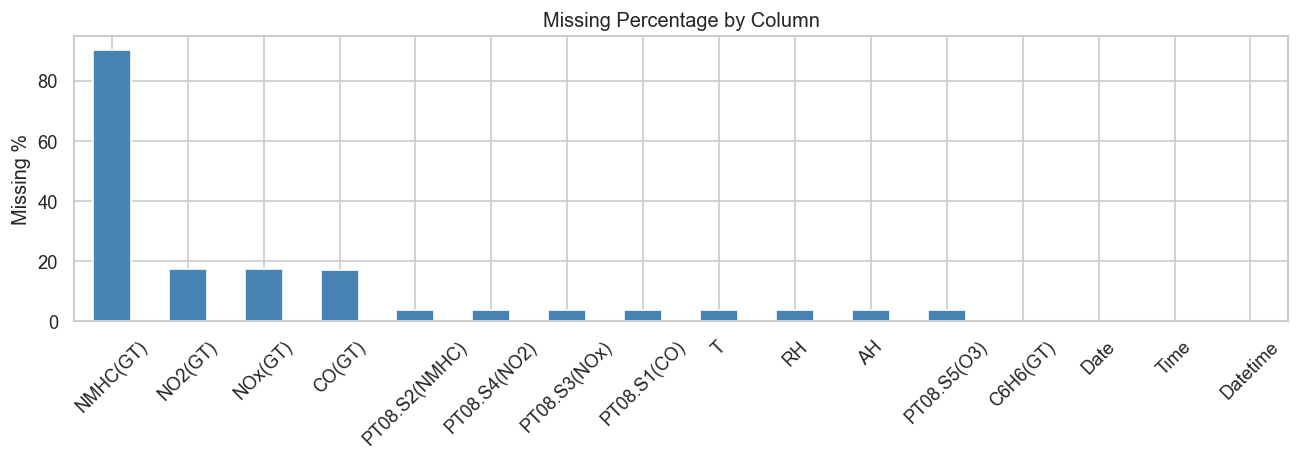

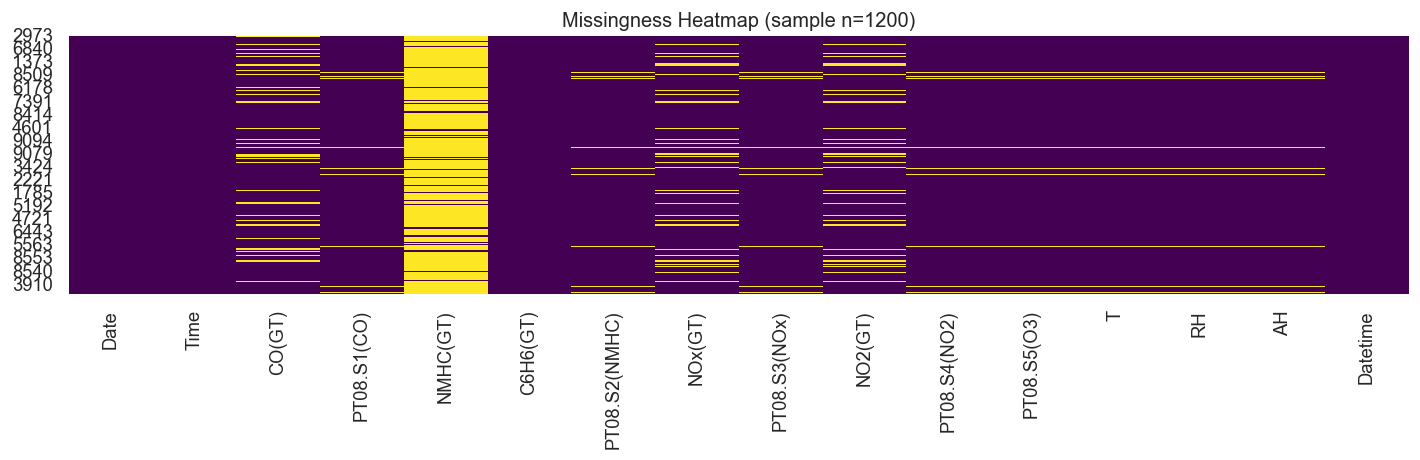

,count,mean,std,min,25%,50%,75%,max
CO(GT),7765.0,-0.216330,21.804850,-200.0000,1.0000,1.8000,2.9000,11.900
PT08.S1(CO),8991.0,1099.833166,217.080037,647.0000,937.0000,1063.0000,1231.0000,2040.000
NMHC(GT),914.0,218.811816,204.459921,7.0000,67.0000,150.0000,297.0000,1189.000
C6H6(GT),9357.0,1.865683,41.380206,-200.0000,4.0000,7.9000,13.6000,63.700
PT08.S2(NMHC),8991.0,939.153376,266.831429,383.0000,734.5000,909.0000,1116.0000,2214.000
NOx(GT),7718.0,246.896735,212.979168,2.0000,98.0000,180.0000,326.0000,1479.000
PT08.S3(NOx),8991.0,835.493605,256.817320,322.0000,658.0000,806.0000,969.5000,2683.000
NO2(GT),7715.0,113.091251,48.370108,2.0000,78.0000,109.0000,142.0000,340.000
PT08.S4(NO2),8991.0,1456.264598,346.206794,551.0000,1227.0000,1463.0000,1674.0000,2775.000
PT08.S5(O3),8991.0,1022.906128,398.484288,221.0000,731.5000,963.0000,1273.5000,2523.000


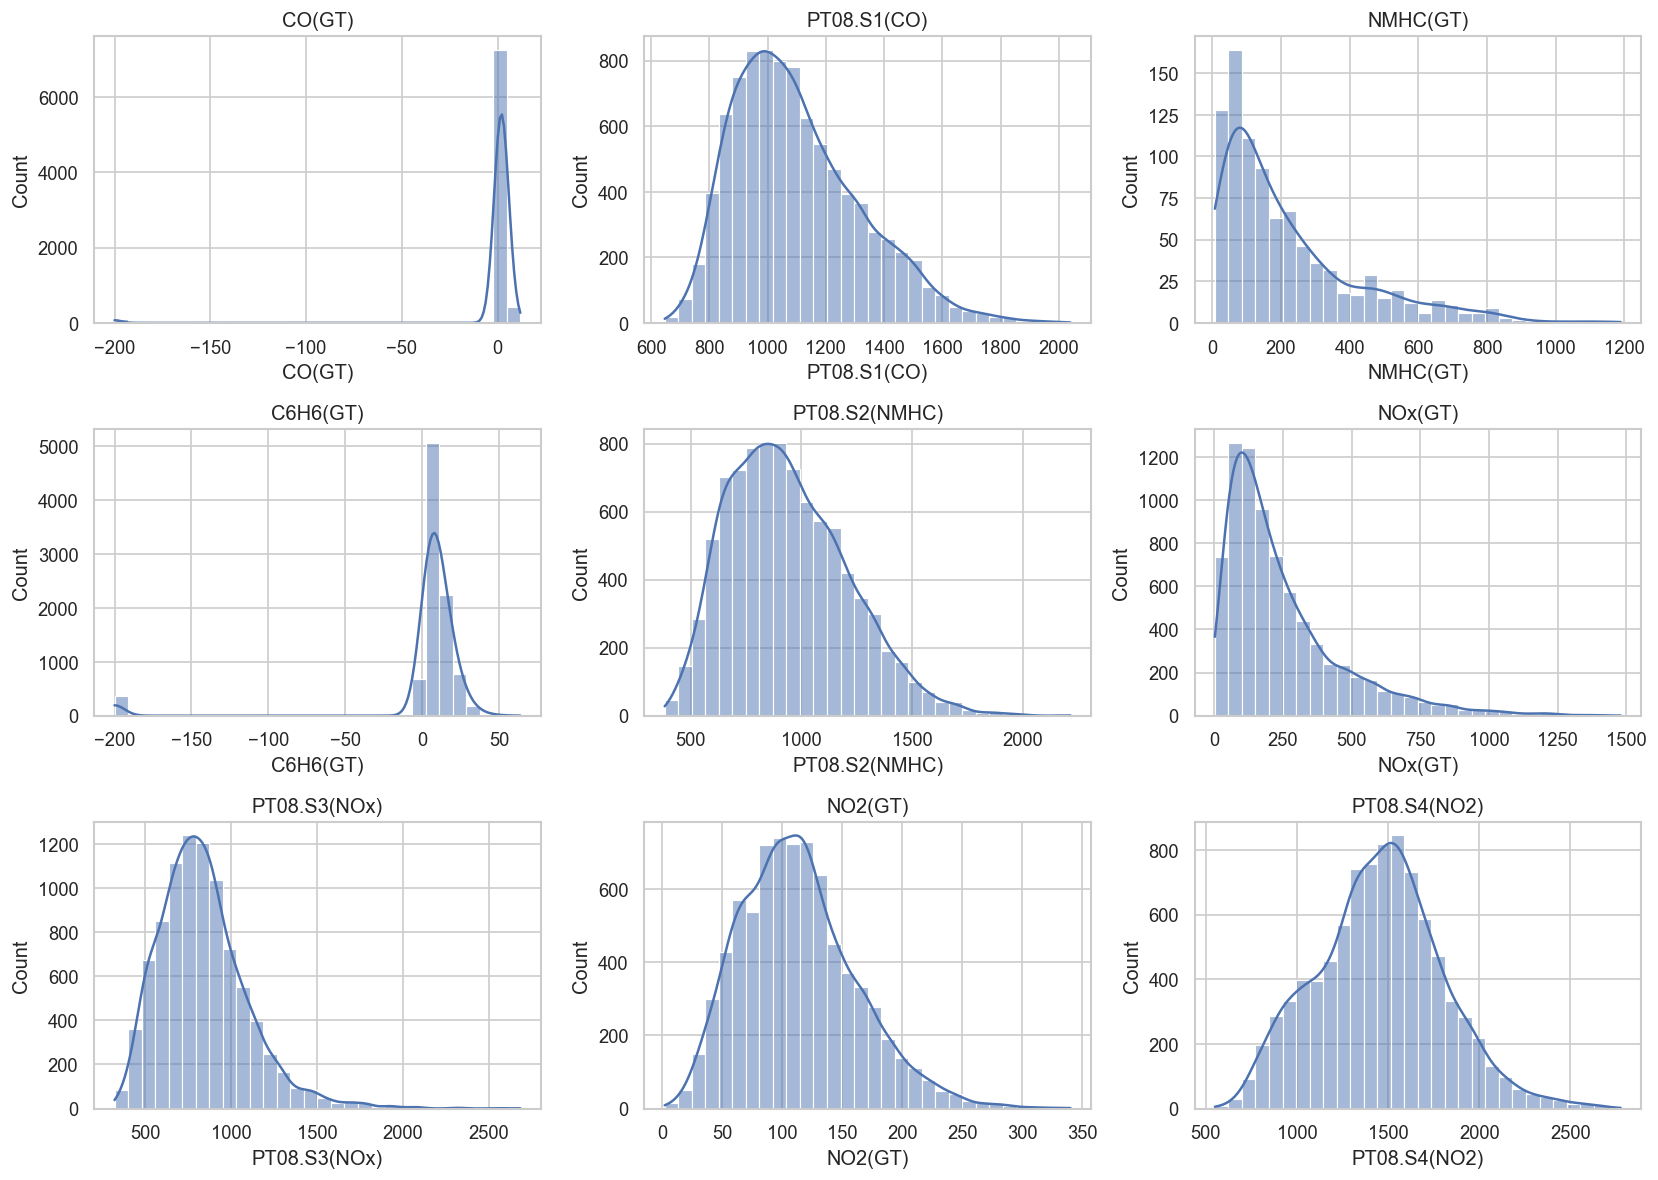

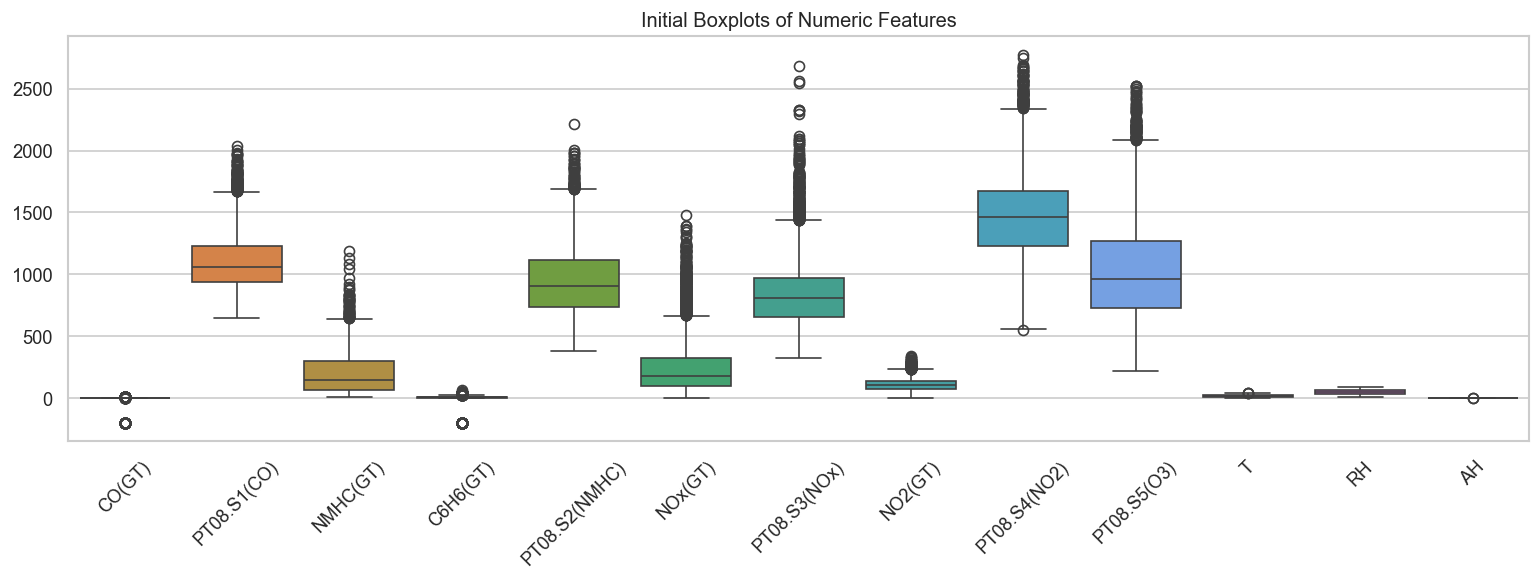

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
missing_pct.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Missing Percentage by Column')
ax.set_ylabel('Missing %')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig(fig, 'fig_missing_percent.png')
plt.show()

sample_n = min(1200, len(df))
miss_matrix = df.sample(sample_n, random_state=RANDOM_SEED).isna().astype(int)
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(miss_matrix, cmap='viridis', cbar=False, ax=ax)
ax.set_title(f'Missingness Heatmap (sample n={sample_n})')
plt.tight_layout()
save_fig(fig, 'fig_missingness_heatmap.png')
plt.show()

numeric_cols = [c for c in df.columns if c not in ['Date', 'Time', 'Datetime']]
display(df[numeric_cols].describe().T)

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.flatten(), numeric_cols[:9]):
    sns.histplot(df[c], kde=True, bins=30, ax=ax)
    ax.set_title(c)
for ax in axes.flatten()[len(numeric_cols[:9]):]:
    ax.axis('off')
plt.tight_layout()
save_fig(fig, 'fig_histograms_numeric_subset.png')
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df[numeric_cols], ax=ax)
ax.set_title('Initial Boxplots of Numeric Features')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig(fig, 'fig_boxplots_initial.png')
plt.show()


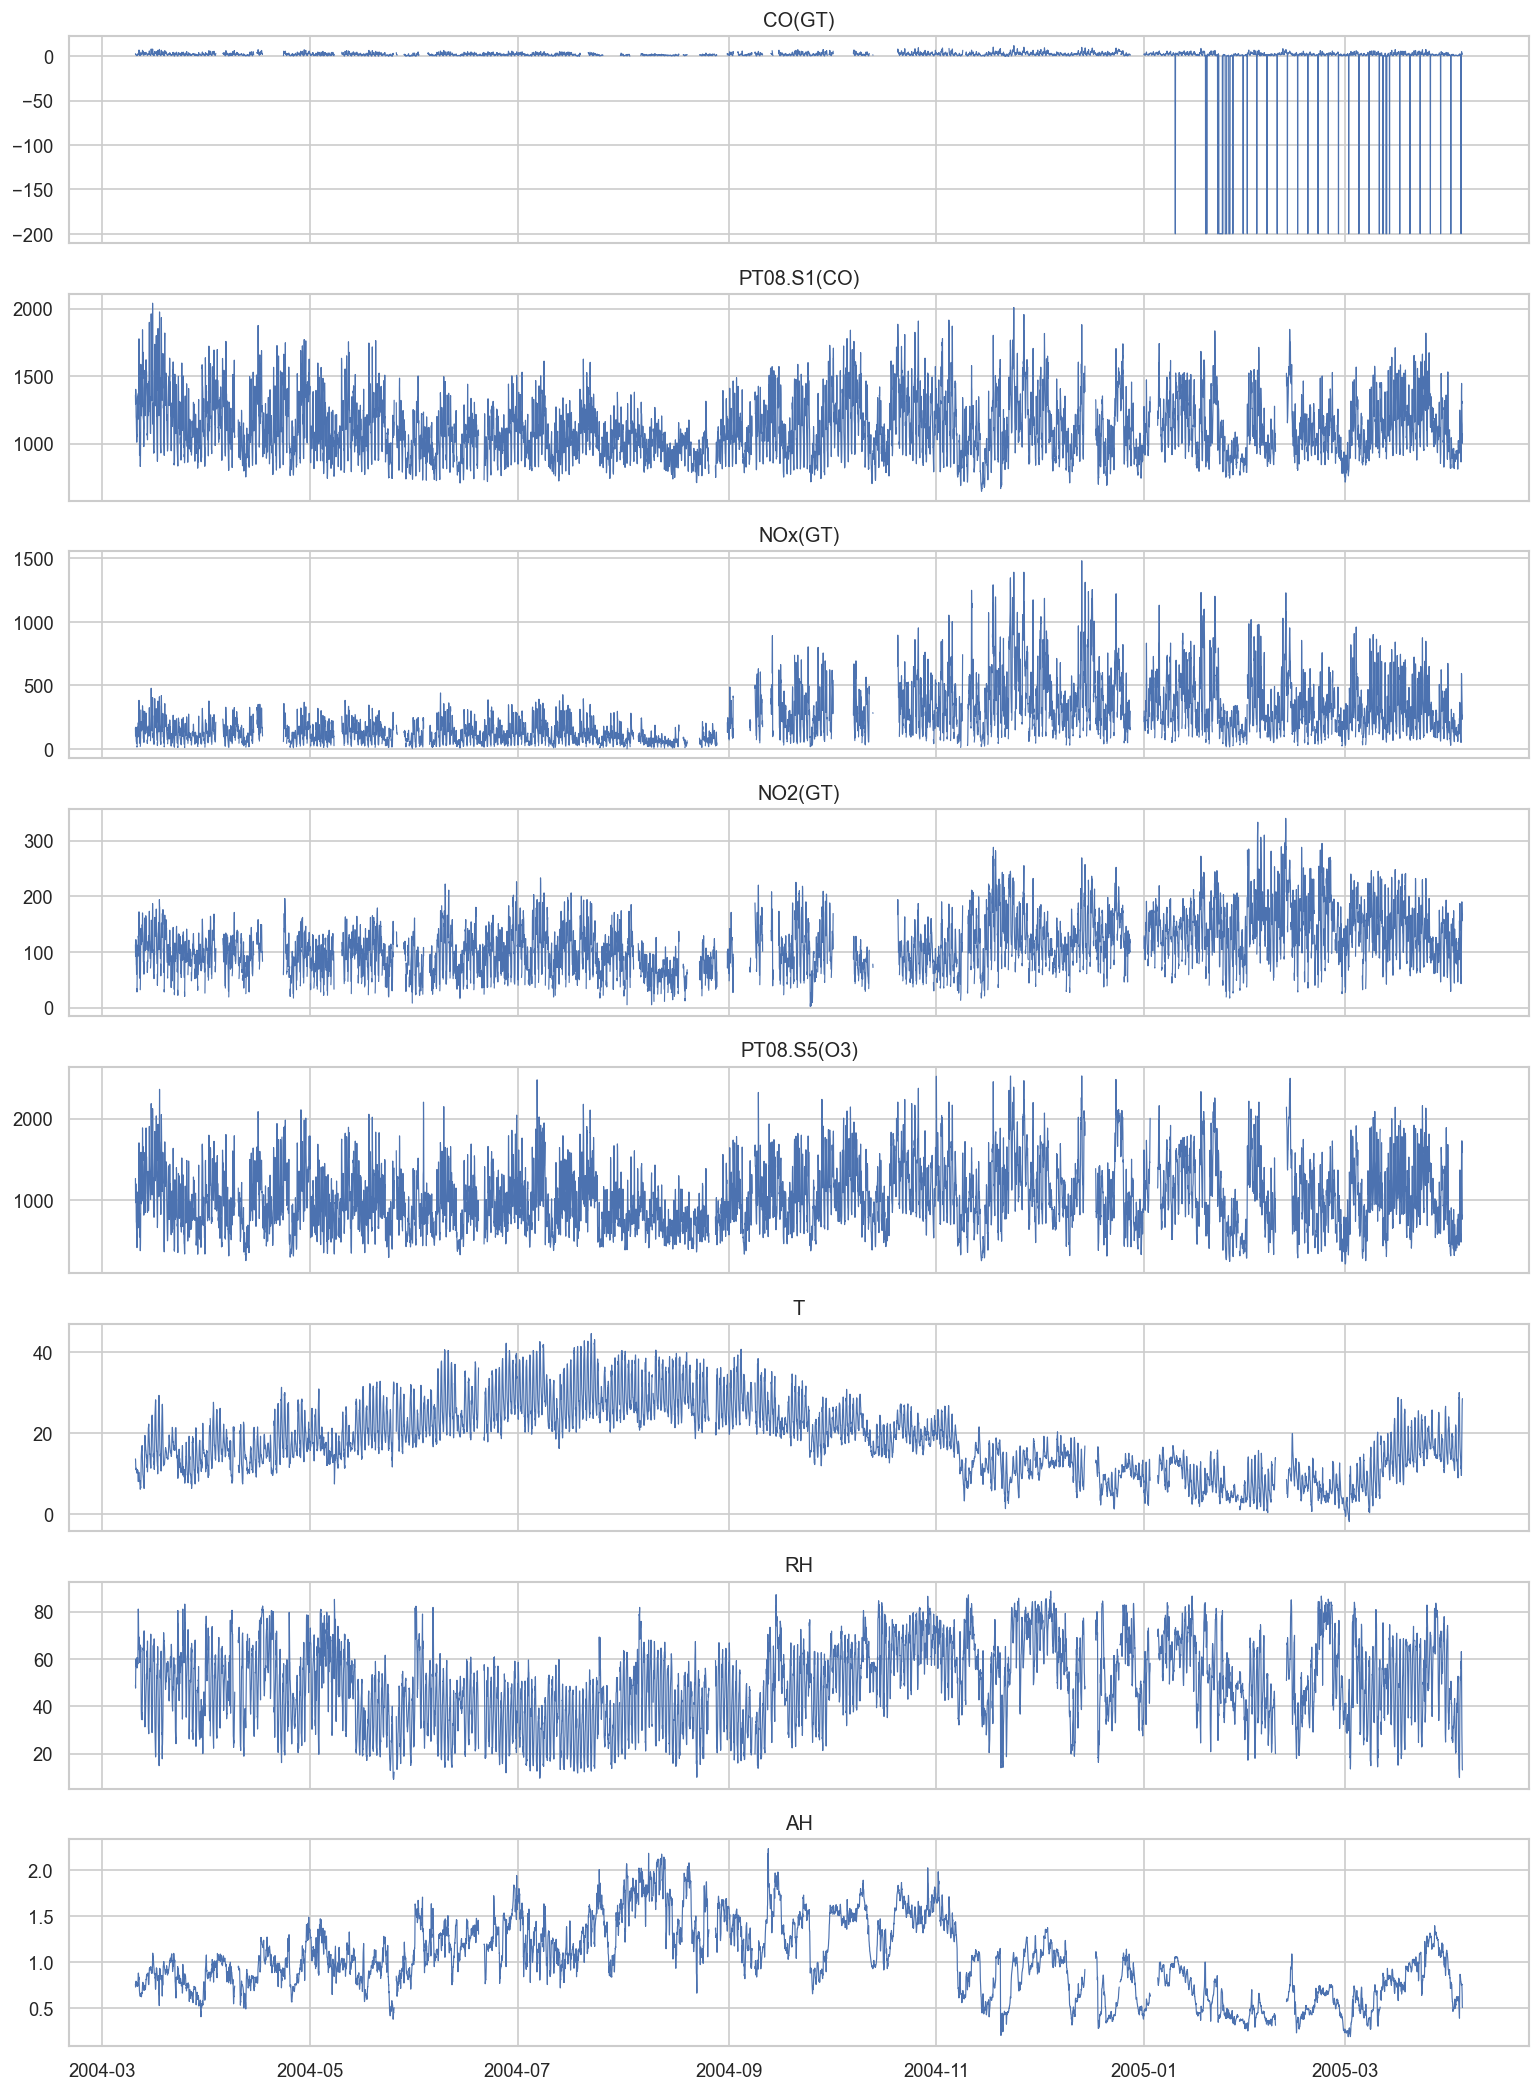

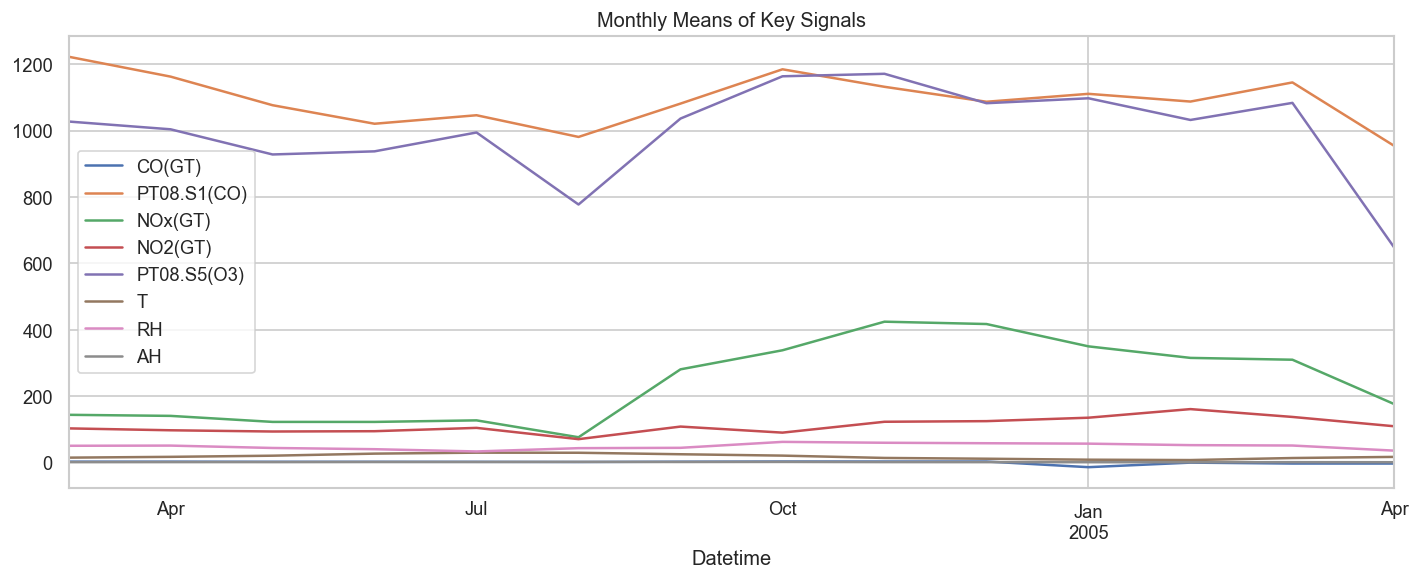

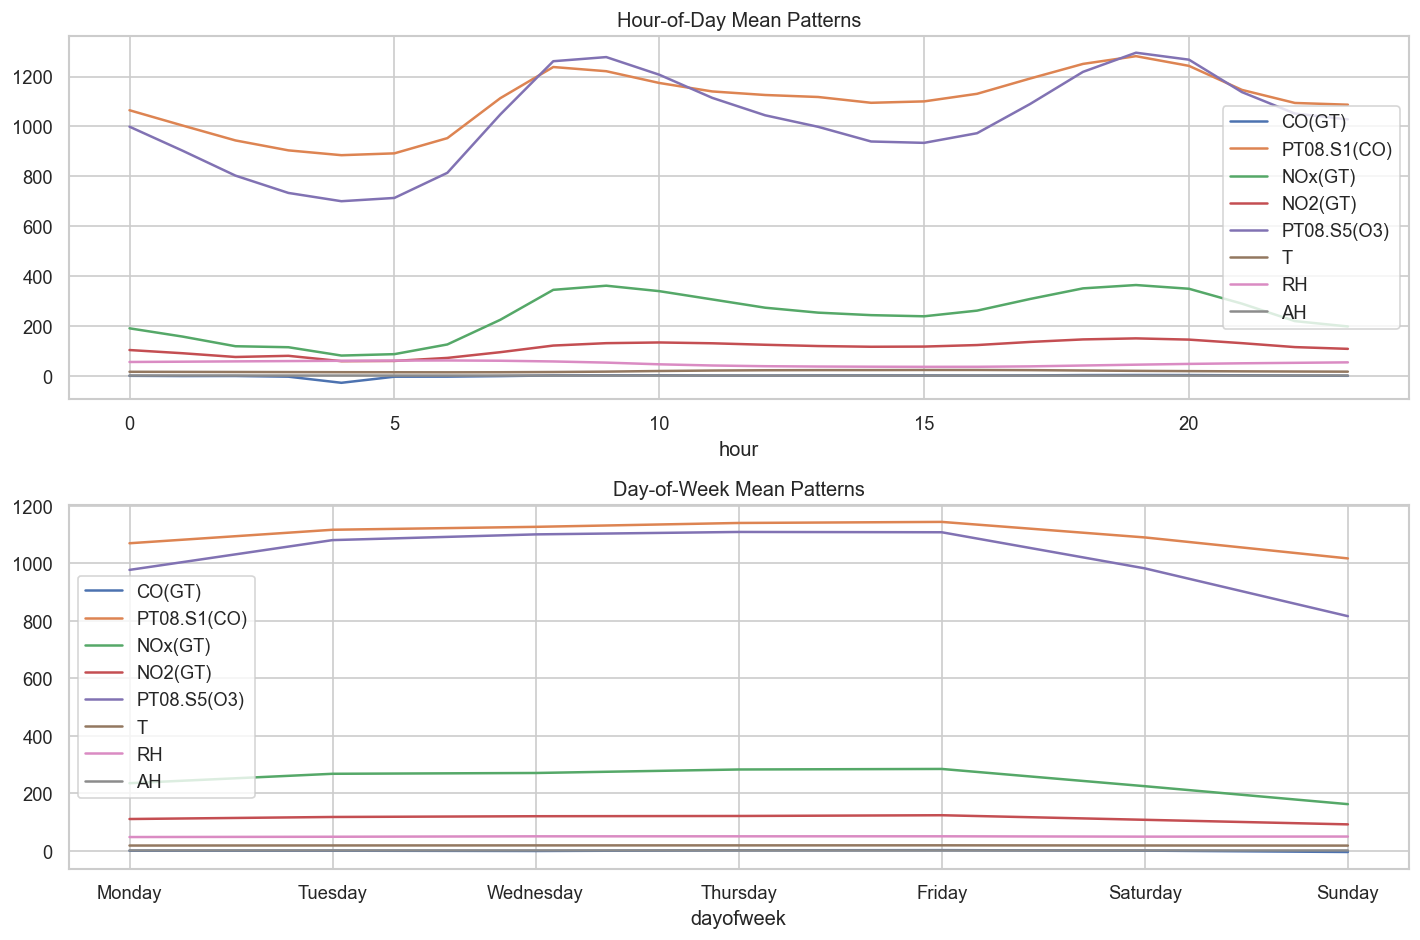

In [6]:
key_cols = ['CO(GT)', 'PT08.S1(CO)', 'NOx(GT)', 'NO2(GT)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
key_cols = [c for c in key_cols if c in df.columns]

plot_df = df.set_index('Datetime')[key_cols]
fig, axes = plt.subplots(len(key_cols), 1, figsize=(13, 2.2 * len(key_cols)), sharex=True)
if len(key_cols) == 1:
    axes = [axes]
for ax, c in zip(axes, key_cols):
    ax.plot(plot_df.index, plot_df[c], lw=0.7)
    ax.set_title(c)
plt.tight_layout()
save_fig(fig, 'fig_time_series_key_signals.png')
plt.show()

monthly = df.set_index('Datetime')[key_cols].resample('ME').mean()
fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(ax=ax)
ax.set_title('Monthly Means of Key Signals')
plt.tight_layout()
save_fig(fig, 'fig_monthly_means.png')
plt.show()

df['hour'] = df['Datetime'].dt.hour
df['dayofweek'] = df['Datetime'].dt.day_name()
hourly = df.groupby('hour')[key_cols].mean()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly = df.groupby('dayofweek')[key_cols].mean().reindex(dow_order)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
hourly.plot(ax=axes[0])
axes[0].set_title('Hour-of-Day Mean Patterns')
weekly.plot(ax=axes[1])
axes[1].set_title('Day-of-Week Mean Patterns')
plt.tight_layout()
save_fig(fig, 'fig_hourly_weekly_patterns.png')
plt.show()


### Feature Selection

Primary feature set for clustering and drift:

`['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']`

This follows the locked decision: sensor + meteorological columns only.


Feature cols: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Period A rows: 4182 range: 2004-03-10 18:00:00 to 2004-08-31 23:00:00
Period B rows: 5088 range: 2004-09-01 00:00:00 to 2005-03-31 23:00:00
Rows outside windows: 87


,feature,q1,q3,iqr,lower,upper,imputer_strategy,scaler,fitted_on
0,PT08.S1(CO),935.0000,1179.750000,244.750000,567.875000,1546.875000,median,RobustScaler,Period A
1,PT08.S2(NMHC),762.0000,1087.000000,325.000000,274.500000,1574.500000,median,RobustScaler,Period A
2,PT08.S3(NOx),745.0000,1022.000000,277.000000,329.500000,1437.500000,median,RobustScaler,Period A
3,PT08.S4(NO2),1454.2500,1752.000000,297.750000,1007.625000,2198.625000,median,RobustScaler,Period A
4,PT08.S5(O3),696.0000,1133.500000,437.500000,39.750000,1789.750000,median,RobustScaler,Period A
5,T,17.1000,28.100000,11.000000,0.600000,44.600000,median,RobustScaler,Period A
6,RH,30.4000,54.100000,23.700000,-5.150000,89.650000,median,RobustScaler,Period A
7,AH,0.9028,1.352475,0.449675,0.228287,2.026988,median,RobustScaler,Period A


,feature,clipped_count,clipped_pct,lower,upper
2,PT08.S3(NOx),121,2.893352,329.500000,1437.500000
3,PT08.S4(NO2),115,2.749880,1007.625000,2198.625000
0,PT08.S1(CO),104,2.486848,567.875000,1546.875000
4,PT08.S5(O3),72,1.721664,39.750000,1789.750000
7,AH,43,1.028216,0.228287,2.026988
1,PT08.S2(NMHC),37,0.884744,274.500000,1574.500000
5,T,0,0.000000,0.600000,44.600000
6,RH,0,0.000000,-5.150000,89.650000


,feature,clipped_count,clipped_pct,lower,upper
3,PT08.S4(NO2),1017,19.988208,1007.625000,2198.625000
4,PT08.S5(O3),328,6.446541,39.750000,1789.750000
0,PT08.S1(CO),213,4.186321,567.875000,1546.875000
2,PT08.S3(NOx),123,2.417453,329.500000,1437.500000
1,PT08.S2(NMHC),112,2.201258,274.500000,1574.500000
5,T,25,0.491352,0.600000,44.600000
7,AH,21,0.412736,0.228287,2.026988
6,RH,0,0.000000,-5.150000,89.650000


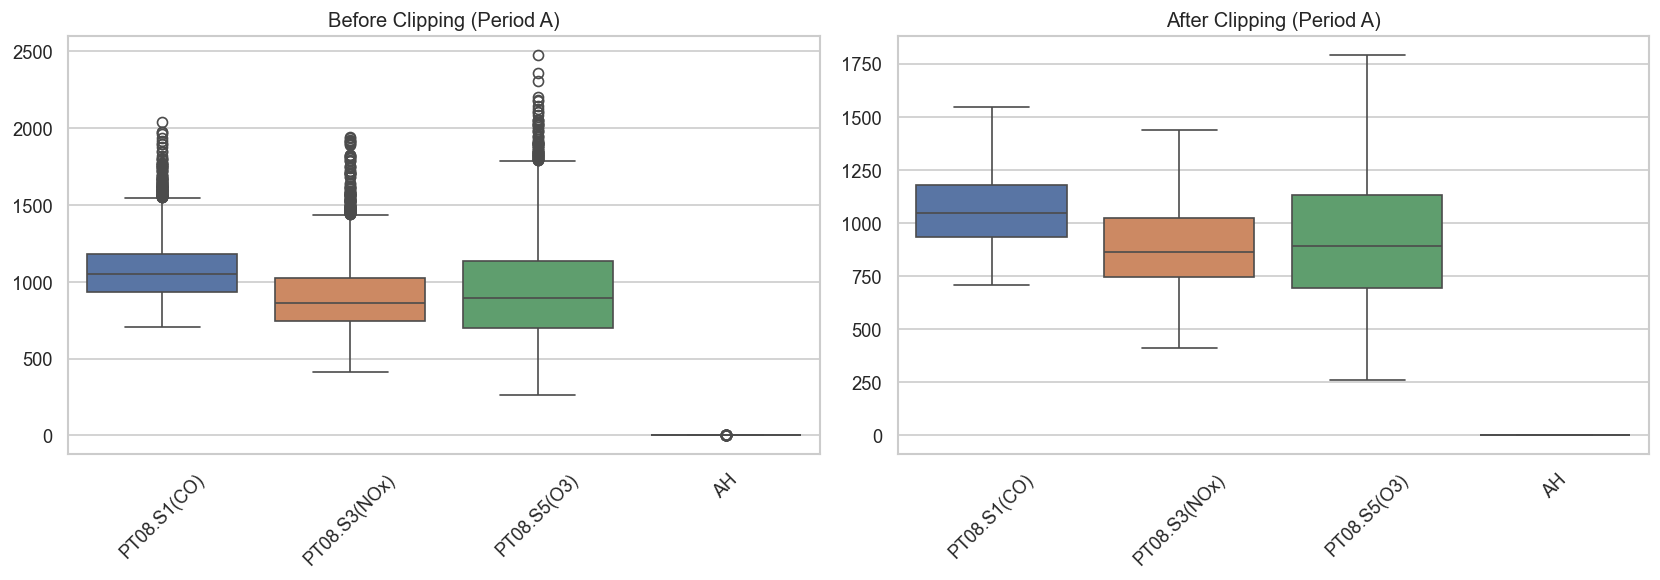

In [7]:
feature_groups = get_feature_groups(df)
feature_cols = feature_groups['sensor_cols'] + feature_groups['meteo_cols']
print('Feature cols:', feature_cols)

df_A = df[(df['Datetime'] >= A_START) & (df['Datetime'] <= A_END)].copy()
df_B = df[(df['Datetime'] >= B_START) & (df['Datetime'] <= B_END)].copy()
outside_rows = len(df) - len(df_A) - len(df_B)

print('Period A rows:', len(df_A), 'range:', df_A['Datetime'].min(), 'to', df_A['Datetime'].max())
print('Period B rows:', len(df_B), 'range:', df_B['Datetime'].min(), 'to', df_B['Datetime'].max())
print('Rows outside windows:', outside_rows)

assert len(df_A) == 4182
assert len(df_B) == 5088
assert outside_rows == 87
assert df_A['Datetime'].max() < df_B['Datetime'].min()

imputer, scaler, prep_meta = fit_preprocessor_on_A(df_A, feature_cols)
clip_bounds = prep_meta['clip_bounds']
X_A_scaled = transform_with_preprocessor(df_A, feature_cols, imputer, scaler, clip_bounds)
X_B_scaled = transform_with_preprocessor(df_B, feature_cols, imputer, scaler, clip_bounds)

prep_table = clip_bounds.reset_index()
prep_table['imputer_strategy'] = prep_meta['imputer_strategy']
prep_table['scaler'] = prep_meta['scaler']
prep_table['fitted_on'] = prep_meta['fitted_on']
display(prep_table)
prep_table.to_csv(OUTPUT_DIR / 'preprocessing_metadata.csv', index=False)

clip_report_A = clipping_report(df_A, feature_cols, imputer, clip_bounds)
clip_report_B = clipping_report(df_B, feature_cols, imputer, clip_bounds)
display(clip_report_A)
display(clip_report_B)
clip_report_A.to_csv(OUTPUT_DIR / 'outlier_clipping_report_A.csv', index=False)
clip_report_B.to_csv(OUTPUT_DIR / 'outlier_clipping_report_B.csv', index=False)

rep_features = [c for c in ['PT08.S1(CO)', 'PT08.S3(NOx)', 'PT08.S5(O3)', 'AH'] if c in feature_cols]
A_imp = pd.DataFrame(imputer.transform(df_A[feature_cols]), columns=feature_cols, index=df_A.index)
A_clip = _clip_with_bounds(A_imp, clip_bounds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=A_imp[rep_features], ax=axes[0])
axes[0].set_title('Before Clipping (Period A)')
axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=A_clip[rep_features], ax=axes[1])
axes[1].set_title('After Clipping (Period A)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig(fig, 'fig_boxplot_before_after_clipping_A.png')
plt.show()


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,11627.799639,0.308971,2477.017138,1.221040
1,3,9003.190821,0.264216,2208.304015,1.286165
2,4,7687.830106,0.246740,1961.959485,1.321111
3,5,6682.479165,0.255454,1849.547567,1.192658
4,6,5932.458410,0.256008,1771.895075,1.138462
5,7,5476.552383,0.245199,1657.046909,1.159930
6,8,5103.422576,0.240878,1567.403635,1.202769
7,9,4760.879572,0.234747,1507.326621,1.166615
8,10,4454.569660,0.235060,1463.512144,1.164577
9,11,4222.700685,0.235068,1412.054463,1.133546


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,16845.842167,0.357435,3795.020576,1.078697
1,3,13011.013991,0.286991,3205.668739,1.258930
2,4,10513.246744,0.298369,3046.964293,1.114528
3,5,9111.229555,0.280741,2831.882414,1.174997
4,6,8072.964848,0.273066,2687.087155,1.152029
5,7,7392.993604,0.268343,2522.606667,1.131807
6,8,6794.231696,0.269682,2416.322117,1.131809
7,9,6296.355305,0.267172,2331.183237,1.143964
8,10,5844.772353,0.269729,2275.413543,1.105804
9,11,5525.376395,0.260601,2195.174228,1.112803


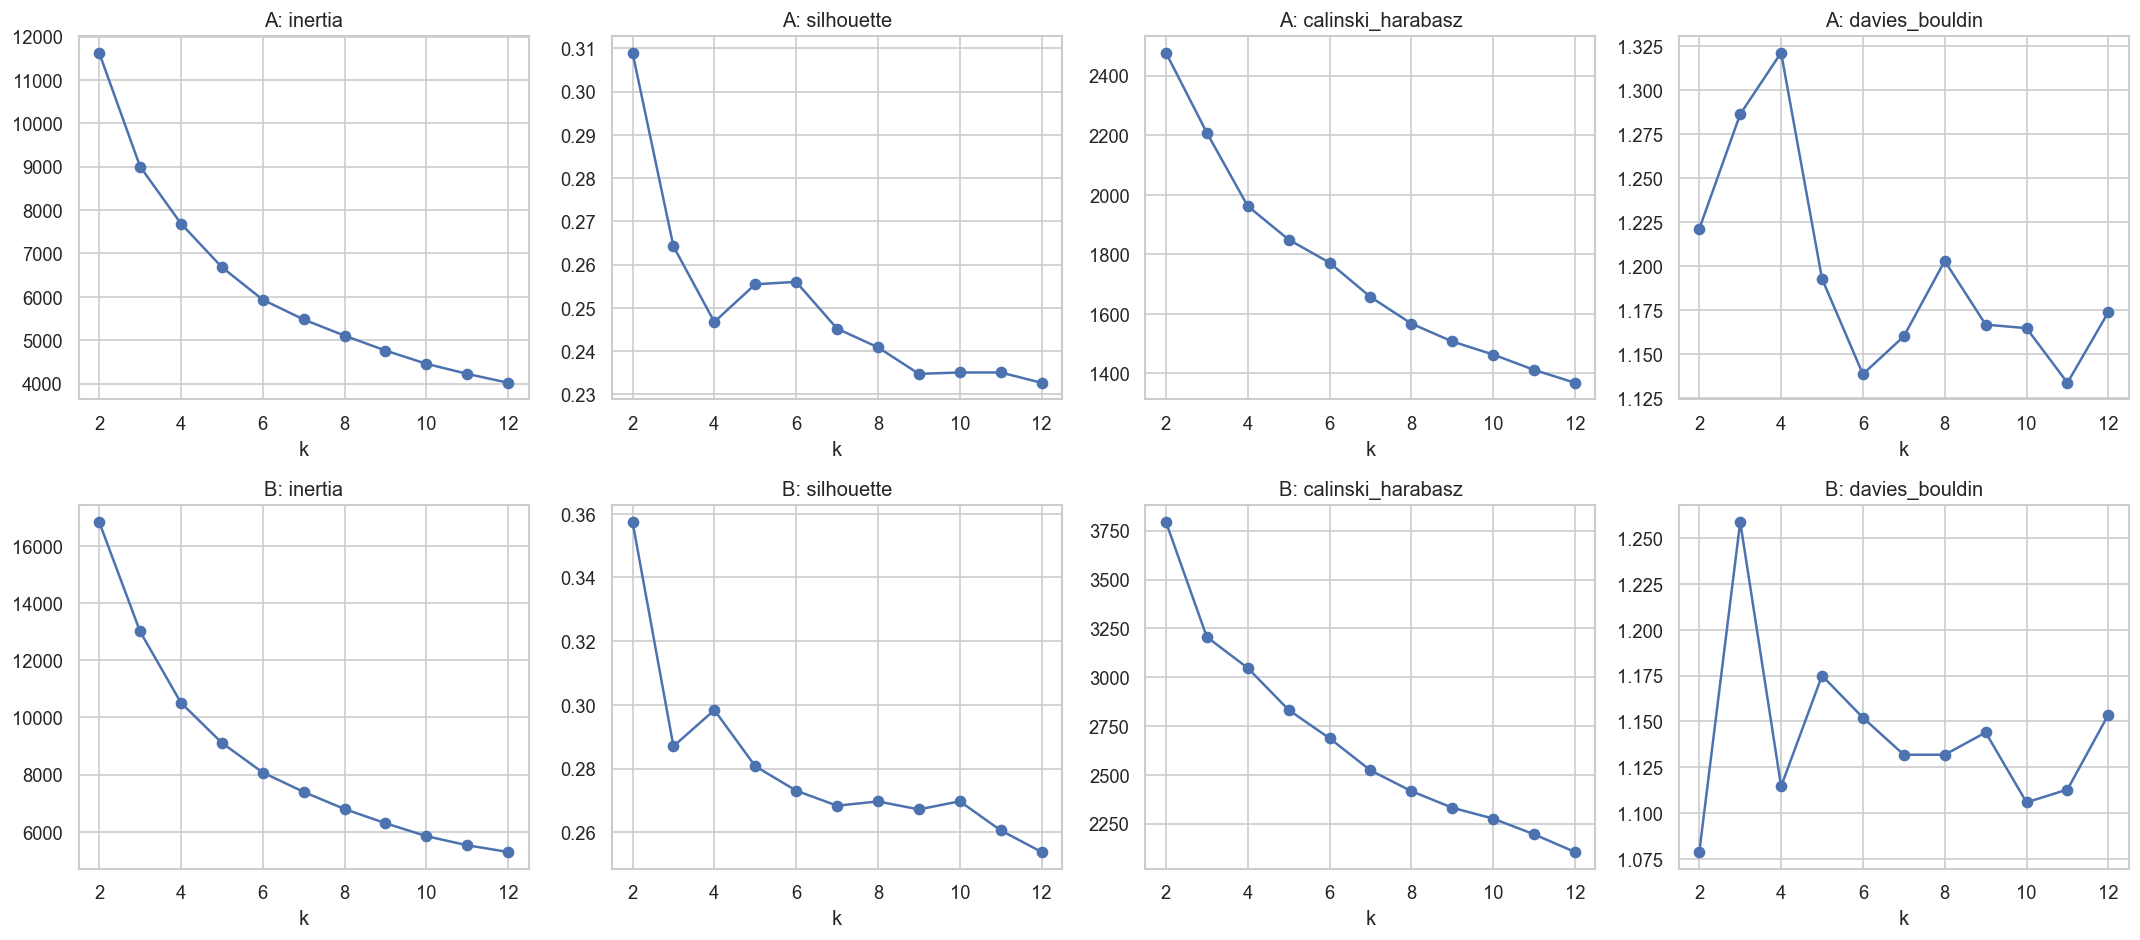

In [8]:
k_values = list(range(2, 13))
k_search_A = kmeans_search(X_A_scaled, k_values, RANDOM_SEED)
k_search_B = kmeans_search(X_B_scaled, k_values, RANDOM_SEED)
display(k_search_A)
display(k_search_B)
k_search_A.to_csv(OUTPUT_DIR / 'k_search_A.csv', index=False)
k_search_B.to_csv(OUTPUT_DIR / 'k_search_B.csv', index=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
metrics = ['inertia', 'silhouette', 'calinski_harabasz', 'davies_bouldin']
for i, metric in enumerate(metrics):
    axes[0, i].plot(k_search_A['k'], k_search_A[metric], marker='o')
    axes[0, i].set_title(f'A: {metric}')
    axes[1, i].plot(k_search_B['k'], k_search_B[metric], marker='o')
    axes[1, i].set_title(f'B: {metric}')
for ax in axes.flatten():
    ax.set_xlabel('k')
plt.tight_layout()
save_fig(fig, 'fig_k_search_metrics_A_B.png')
plt.show()


Selected kA = 2
Selected kB = 2


,n_samples
cluster,
0,1733
1,2449


,n_samples
cluster,
0,1924
1,3164


,period,k,silhouette,calinski_harabasz,davies_bouldin
0,A,2,0.308971,2477.017138,1.221040
1,B,2,0.357435,3795.020576,1.078697


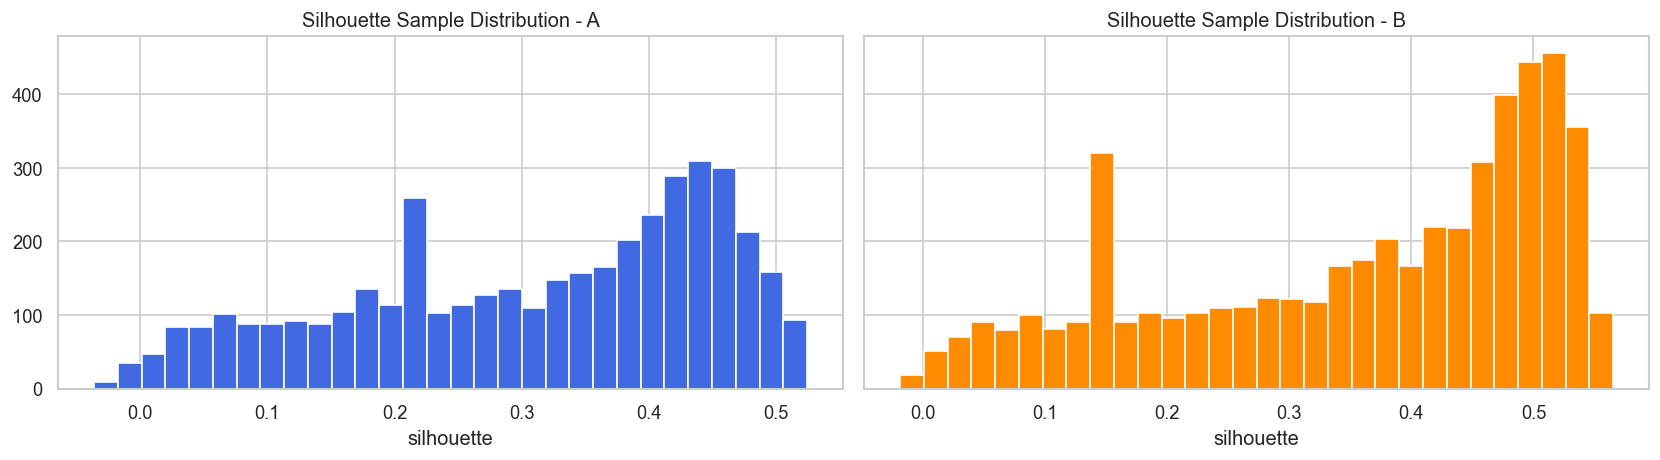

,cluster,n_samples,mean_PT08.S1(CO),mean_PT08.S2(NMHC),mean_PT08.S3(NOx),mean_PT08.S4(NO2),mean_PT08.S5(O3),mean_T,mean_RH,mean_AH,median_PT08.S1(CO),median_PT08.S2(NMHC),median_PT08.S3(NOx),median_PT08.S4(NO2),median_PT08.S5(O3),median_T,median_RH,median_AH
0,0,1733,1246.545874,1153.045586,719.624928,1844.972879,1234.780150,25.091691,39.764282,1.186669,1210.0,1122.0,723.0,1795.0,1194.0,25.2,38.80,1.13020
1,1,2449,952.893534,773.568966,1039.179741,1458.726293,722.482328,21.751983,45.349353,1.121423,949.0,782.0,995.0,1471.0,723.0,21.2,46.15,1.05165


,cluster,n_samples,mean_PT08.S1(CO),mean_PT08.S2(NMHC),mean_PT08.S3(NOx),mean_PT08.S4(NO2),mean_PT08.S5(O3),mean_T,mean_RH,mean_AH,median_PT08.S1(CO),median_PT08.S2(NMHC),median_PT08.S3(NOx),median_PT08.S4(NO2),median_PT08.S5(O3),median_T,median_RH,median_AH
0,0,1924,1339.568607,1224.695426,564.232848,1653.177755,1484.573805,17.973389,55.958420,1.153845,1316.0,1200.0,552.0,1602.5,1463.0,18.3,57.65,1.1289
1,1,3164,976.194055,763.210113,919.056372,1108.994192,843.293475,11.860881,53.909019,0.781779,973.0,764.0,869.0,1112.0,846.0,11.4,54.60,0.7219


In [9]:
kA = select_best_k(k_search_A)
kB = select_best_k(k_search_B)
print('Selected kA =', kA)
print('Selected kB =', kB)

model_A, labels_A = fit_kmeans(X_A_scaled, kA, RANDOM_SEED)
model_B, labels_B = fit_kmeans(X_B_scaled, kB, RANDOM_SEED)
df_A['cluster'] = labels_A
df_B['cluster'] = labels_B

sizes_A = df_A['cluster'].value_counts().sort_index().rename('n_samples').to_frame()
sizes_B = df_B['cluster'].value_counts().sort_index().rename('n_samples').to_frame()
display(sizes_A)
display(sizes_B)
sizes_A.to_csv(OUTPUT_DIR / 'cluster_sizes_A.csv')
sizes_B.to_csv(OUTPUT_DIR / 'cluster_sizes_B.csv')

metrics_final = pd.DataFrame({
    'period': ['A', 'B'],
    'k': [kA, kB],
    'silhouette': [silhouette_score(X_A_scaled, labels_A), silhouette_score(X_B_scaled, labels_B)],
    'calinski_harabasz': [calinski_harabasz_score(X_A_scaled, labels_A), calinski_harabasz_score(X_B_scaled, labels_B)],
    'davies_bouldin': [davies_bouldin_score(X_A_scaled, labels_A), davies_bouldin_score(X_B_scaled, labels_B)],
})
display(metrics_final)
metrics_final.to_csv(OUTPUT_DIR / 'final_cluster_metrics.csv', index=False)

sil_A = silhouette_samples(X_A_scaled, labels_A)
sil_B = silhouette_samples(X_B_scaled, labels_B)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].hist(sil_A, bins=30, color='royalblue')
axes[0].set_title('Silhouette Sample Distribution - A')
axes[0].set_xlabel('silhouette')
axes[1].hist(sil_B, bins=30, color='darkorange')
axes[1].set_title('Silhouette Sample Distribution - B')
axes[1].set_xlabel('silhouette')
plt.tight_layout()
save_fig(fig, 'fig_silhouette_distributions.png')
plt.show()

cluster_profiles_A = cluster_profile_table(df_A, labels_A, feature_cols)
cluster_profiles_B = cluster_profile_table(df_B, labels_B, feature_cols)
display(cluster_profiles_A)
display(cluster_profiles_B)
cluster_profiles_A.to_csv(OUTPUT_DIR / 'cluster_profiles_A.csv', index=False)
cluster_profiles_B.to_csv(OUTPUT_DIR / 'cluster_profiles_B.csv', index=False)


Cluster mapping A->B: {0: 0, 1: 1}


,B_0,B_1
A_0,1.423994,3.274081
A_1,3.194404,1.564455


,cluster_A,cluster_B,centroid_shift_l2
1,1,1,1.564455
0,0,0,1.423994


,cluster_A,cluster_B,delta_PT08.S1(CO),delta_PT08.S2(NMHC),delta_PT08.S3(NOx),delta_PT08.S4(NO2),delta_PT08.S5(O3),delta_T,delta_RH,delta_AH
0,0,0,0.361940,0.201127,-0.561566,-0.630454,0.505373,-0.646239,0.682118,-0.071873
1,1,1,0.097123,-0.019172,-0.426098,-0.948354,0.264633,-0.829285,0.332651,-0.698845


,cluster_id,prop_A,prop_B_aligned,abs_diff,tvd,kl_a_to_b,js
0,0,0.414395,0.378145,0.03625,0.03625,0.002762,0.000687
1,1,0.585605,0.621855,0.03625,0.03625,0.002762,0.000687


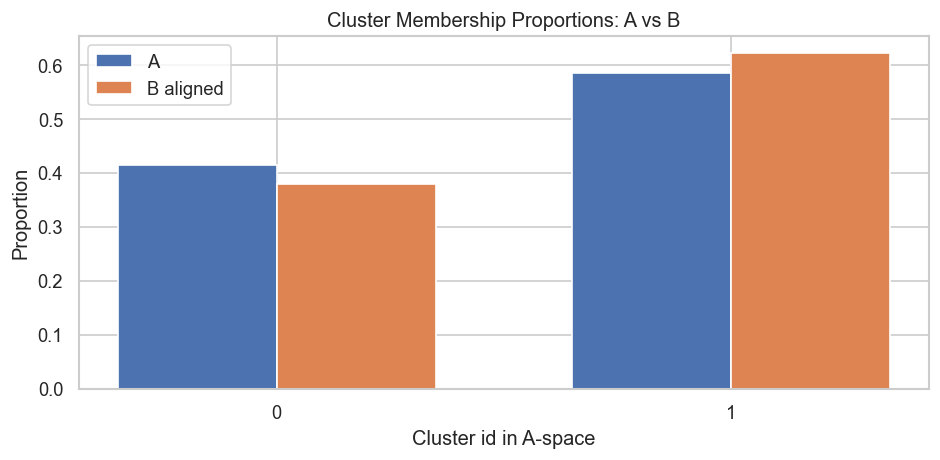

In [10]:
cent_A = model_A.cluster_centers_
cent_B = model_B.cluster_centers_
mapping_A_to_B = align_clusters_by_centroid(cent_A, cent_B)
print('Cluster mapping A->B:', mapping_A_to_B)

dmat = cdist(cent_A, cent_B)
dmat_df = pd.DataFrame(dmat, index=[f'A_{i}' for i in range(cent_A.shape[0])], columns=[f'B_{j}' for j in range(cent_B.shape[0])])
display(dmat_df)
dmat_df.to_csv(OUTPUT_DIR / 'centroid_distance_matrix.csv')

shift_rows = []
for a_idx, b_idx in mapping_A_to_B.items():
    shift_rows.append({'cluster_A': a_idx, 'cluster_B': b_idx, 'centroid_shift_l2': float(np.linalg.norm(cent_A[a_idx] - cent_B[b_idx]))})
centroid_shift_df = pd.DataFrame(shift_rows).sort_values('centroid_shift_l2', ascending=False)
display(centroid_shift_df)
centroid_shift_df.to_csv(OUTPUT_DIR / 'centroid_shift_summary.csv', index=False)

feature_delta_rows = []
for a_idx, b_idx in mapping_A_to_B.items():
    delta = cent_B[b_idx] - cent_A[a_idx]
    row = {'cluster_A': a_idx, 'cluster_B': b_idx}
    row.update({f'delta_{f}': delta[i] for i, f in enumerate(feature_cols)})
    feature_delta_rows.append(row)
feature_delta_df = pd.DataFrame(feature_delta_rows)
display(feature_delta_df)
feature_delta_df.to_csv(OUTPUT_DIR / 'centroid_feature_deltas.csv', index=False)

prop_A = df_A['cluster'].value_counts(normalize=True).sort_index()
inv_map = {v: k for k, v in mapping_A_to_B.items()}
aligned_B = df_B['cluster'].map(inv_map)
prop_B = aligned_B.value_counts(normalize=True).sort_index()
cluster_ids = sorted(set(prop_A.index).union(set(prop_B.index)))
pA = np.array([prop_A.get(i, 0.0) for i in cluster_ids], dtype=float)
pB = np.array([prop_B.get(i, 0.0) for i in cluster_ids], dtype=float)
kl_ab, js_ab = safe_kl_js(pA, pB)
tvd = 0.5 * np.abs(pA - pB).sum()

dist_table = pd.DataFrame({
    'cluster_id': cluster_ids,
    'prop_A': pA,
    'prop_B_aligned': pB,
    'abs_diff': np.abs(pA - pB),
    'tvd': tvd,
    'kl_a_to_b': kl_ab,
    'js': js_ab,
})
display(dist_table)
dist_table.to_csv(OUTPUT_DIR / 'cluster_distribution_drift.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(cluster_ids))
w = 0.35
ax.bar(x - w / 2, pA, width=w, label='A')
ax.bar(x + w / 2, pB, width=w, label='B aligned')
ax.set_xticks(x)
ax.set_xticklabels(cluster_ids)
ax.set_title('Cluster Membership Proportions: A vs B')
ax.set_xlabel('Cluster id in A-space')
ax.set_ylabel('Proportion')
ax.legend()
plt.tight_layout()
save_fig(fig, 'fig_cluster_proportion_comparison.png')
plt.show()


,feature,a_min,a_max,kl_a_to_b,js
0,PT08.S4(NO2),955.0000,2746.0000,0.569387,0.162621
1,T,6.1000,44.6000,0.746244,0.156051
2,AH,0.3754,2.1806,0.439344,0.096871
3,PT08.S3(NOx),410.0000,1941.0000,0.229899,0.065876
4,RH,9.2000,85.2000,0.300052,0.065815
5,PT08.S5(O3),263.0000,2475.0000,0.101257,0.027003
6,PT08.S2(NMHC),437.0000,1776.0000,0.040489,0.010852
7,PT08.S1(CO),708.0000,2040.0000,0.034855,0.009016


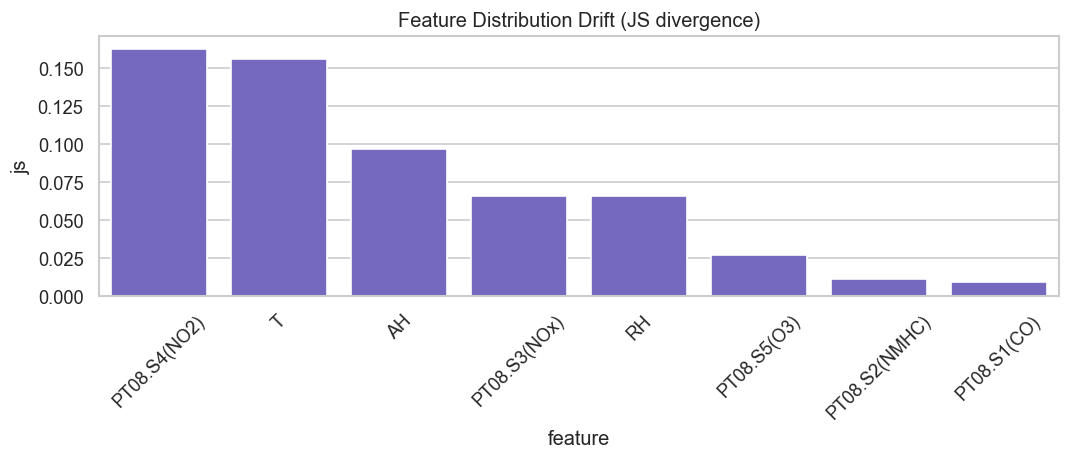

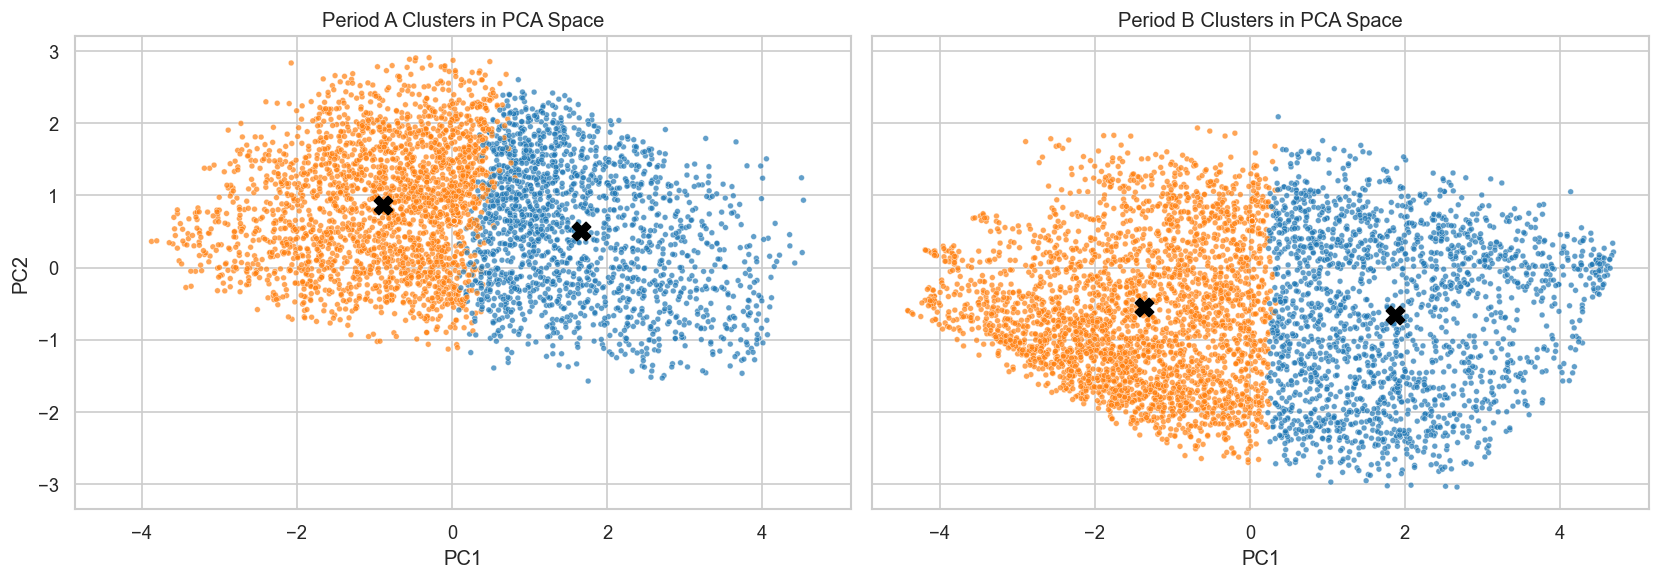

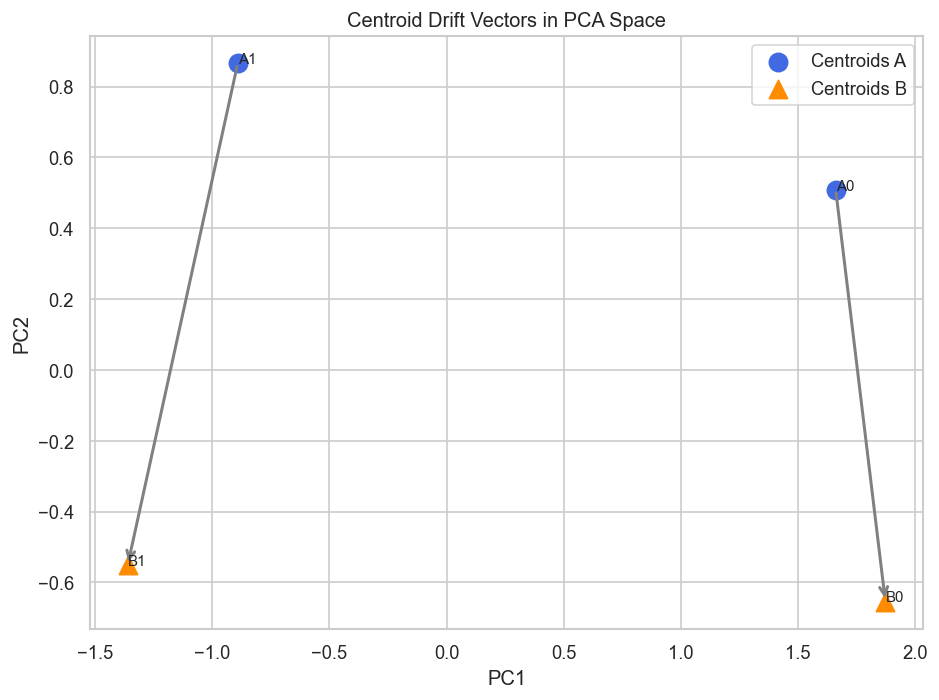

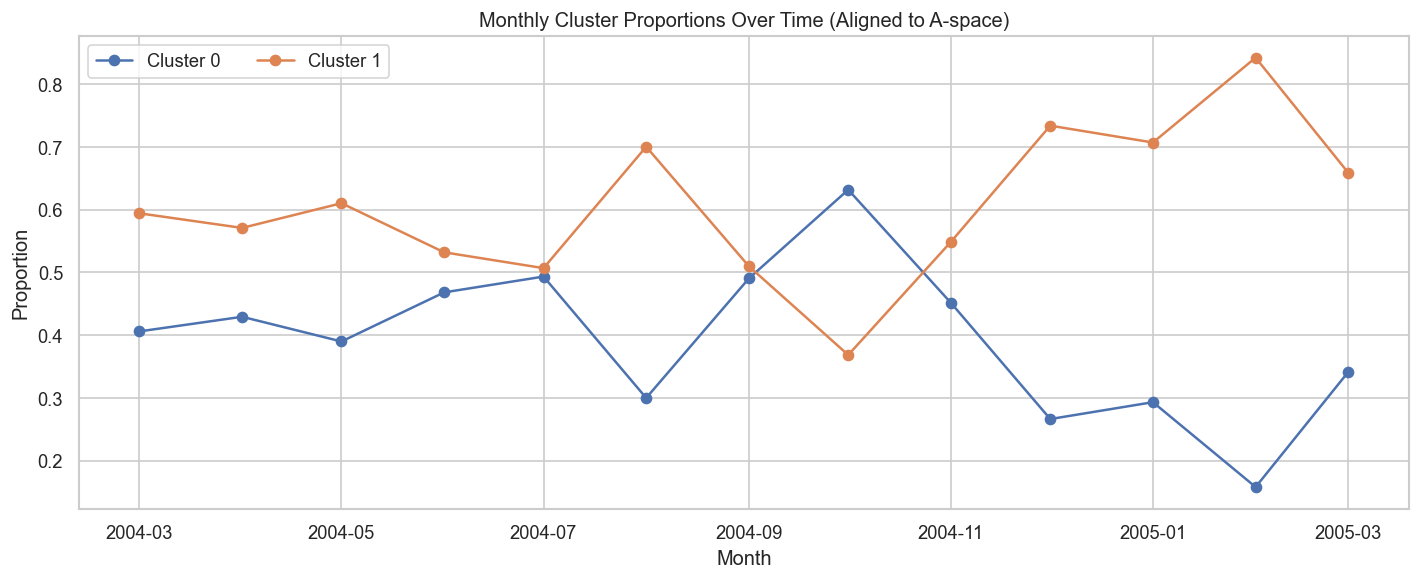

In [11]:
feature_js = feature_js_drift(df_A, df_B, feature_cols, bins=30)
display(feature_js)
feature_js.to_csv(OUTPUT_DIR / 'feature_js_drift.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=feature_js, x='feature', y='js', color='slateblue', ax=ax)
ax.set_title('Feature Distribution Drift (JS divergence)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig(fig, 'fig_feature_js_drift.png')
plt.show()

X_all = np.vstack([X_A_scaled, X_B_scaled])
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_all_pca = pca.fit_transform(X_all)
X_A_pca = X_all_pca[:len(df_A)]
X_B_pca = X_all_pca[len(df_A):]
cent_A_pca = pca.transform(cent_A)
cent_B_pca = pca.transform(cent_B)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
sns.scatterplot(x=X_A_pca[:, 0], y=X_A_pca[:, 1], hue=labels_A, s=12, alpha=0.7, palette='tab10', ax=axes[0], legend=False)
axes[0].scatter(cent_A_pca[:, 0], cent_A_pca[:, 1], marker='X', s=120, c='black')
axes[0].set_title('Period A Clusters in PCA Space')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
sns.scatterplot(x=X_B_pca[:, 0], y=X_B_pca[:, 1], hue=labels_B, s=12, alpha=0.7, palette='tab10', ax=axes[1], legend=False)
axes[1].scatter(cent_B_pca[:, 0], cent_B_pca[:, 1], marker='X', s=120, c='black')
axes[1].set_title('Period B Clusters in PCA Space')
axes[1].set_xlabel('PC1')
plt.tight_layout()
save_fig(fig, 'fig_pca_clusters_A_B.png')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cent_A_pca[:, 0], cent_A_pca[:, 1], c='royalblue', s=120, label='Centroids A')
ax.scatter(cent_B_pca[:, 0], cent_B_pca[:, 1], c='darkorange', s=120, marker='^', label='Centroids B')
for a_idx, b_idx in mapping_A_to_B.items():
    x1, y1 = cent_A_pca[a_idx]
    x2, y2 = cent_B_pca[b_idx]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', lw=1.8, color='gray'))
    ax.text(x1, y1, f'A{a_idx}', fontsize=9)
    ax.text(x2, y2, f'B{b_idx}', fontsize=9)
ax.set_title('Centroid Drift Vectors in PCA Space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
save_fig(fig, 'fig_pca_centroid_drift_vectors.png')
plt.show()

timeline = pd.concat([
    df_A[['Datetime', 'cluster']].assign(period='A'),
    df_B[['Datetime', 'cluster']].assign(period='B'),
], axis=0).sort_values('Datetime')
timeline['cluster_aligned'] = np.where(timeline['period'] == 'A', timeline['cluster'], timeline['cluster'].map(inv_map))
timeline['month'] = timeline['Datetime'].dt.to_period('M').dt.to_timestamp()
monthly_counts = (
    timeline.dropna(subset=['cluster_aligned'])
    .groupby(['month', 'cluster_aligned'])
    .size()
    .rename('count')
    .reset_index()
)
monthly_counts['proportion'] = monthly_counts['count'] / monthly_counts.groupby('month')['count'].transform('sum')
monthly_props = monthly_counts[['month', 'cluster_aligned', 'proportion']]
monthly_props.to_csv(OUTPUT_DIR / 'monthly_cluster_proportions.csv', index=False)
fig, ax = plt.subplots(figsize=(12, 5))
for cid in sorted(monthly_props['cluster_aligned'].unique()):
    sub = monthly_props[monthly_props['cluster_aligned'] == cid]
    ax.plot(sub['month'], sub['proportion'], marker='o', lw=1.5, label=f'Cluster {int(cid)}')
ax.set_title('Monthly Cluster Proportions Over Time (Aligned to A-space)')
ax.set_xlabel('Month')
ax.set_ylabel('Proportion')
ax.legend(ncol=3)
plt.tight_layout()
save_fig(fig, 'fig_monthly_cluster_proportions.png')
plt.show()


## Conclusion and Research Review

### Findings
- cluster structure is learned separately in each period under a fixed baseline preprocessing reference (Period A)
- drift is observed in centroid positions, membership proportions, and feature distributions
- KL/JS + TVD provide compact shift quantification

### Interpretation
- observed changes can reflect traffic/activity schedules and seasonality
- meteorological context (T, RH, AH) contributes to cluster regime changes
- possible sensor aging/calibration drift should be considered as an alternative explanation

### Research linkage
This implementation aligns with concept drift monitoring practice:
- baseline vs future windows under a stable transform
- divergence monitoring with JS (symmetric, stable)
- extension path: rolling-window tracking and alert thresholds


In [12]:
required_csv = [
    'k_search_A.csv',
    'k_search_B.csv',
    'cluster_profiles_A.csv',
    'cluster_profiles_B.csv',
    'cluster_distribution_drift.csv',
    'feature_js_drift.csv',
]
print('Output artifact check:')
for f in required_csv:
    p = OUTPUT_DIR / f
    print(f'- {f}:', 'OK' if p.exists() else 'MISSING')

figs = sorted([p.name for p in OUTPUT_DIR.glob('fig_*.png')])
print('Figure files:', len(figs))
for name in figs:
    print('-', name)

top_feature = feature_js.iloc[0]['feature'] if len(feature_js) else 'N/A'
summary = [
    f'Rows after cleaning: {len(df)}',
    f'Period A rows: {len(df_A)} | Period B rows: {len(df_B)} | Outside windows: {len(df) - len(df_A) - len(df_B)}',
    f'Selected k values: kA={kA}, kB={kB}',
    f'Cluster drift JS: {js_ab:.4f} | KL(A||B): {kl_ab:.4f} | TVD: {tvd:.4f}',
    f'Top drifting feature by JS: {top_feature}',
    'All required Q2 CSV artifacts were exported to notebooks/Q2/outputs/',
]
print('Notebook summary:')
for item in summary:
    print('-', item)


Output artifact check:
- k_search_A.csv: OK
- k_search_B.csv: OK
- cluster_profiles_A.csv: OK
- cluster_profiles_B.csv: OK
- cluster_distribution_drift.csv: OK
- feature_js_drift.csv: OK
Figure files: 15
- fig_boxplot_before_after_clipping_A.png
- fig_boxplots_initial.png
- fig_cluster_proportion_comparison.png
- fig_feature_js_drift.png
- fig_histograms_numeric_subset.png
- fig_hourly_weekly_patterns.png
- fig_k_search_metrics_A_B.png
- fig_missing_percent.png
- fig_missingness_heatmap.png
- fig_monthly_cluster_proportions.png
- fig_monthly_means.png
- fig_pca_centroid_drift_vectors.png
- fig_pca_clusters_A_B.png
- fig_silhouette_distributions.png
- fig_time_series_key_signals.png
Notebook summary:
- Rows after cleaning: 9357
- Period A rows: 4182 | Period B rows: 5088 | Outside windows: 87
- Selected k values: kA=2, kB=2
- Cluster drift JS: 0.0007 | KL(A||B): 0.0028 | TVD: 0.0363
- Top drifting feature by JS: PT08.S4(NO2)
- All required Q2 CSV artifacts were exported to notebooks/Q2/